In [137]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import requests
from bs4 import BeautifulSoup
from io import BytesIO

In [138]:
response=requests.get("https://datamb.football/midfielders/")

In [139]:
response.status_code

200

In [140]:
soup=BeautifulSoup(response.text,"html.parser")

In [141]:
soup.select('g[cursor="pointer"]')

[]

In [142]:
response.status_code

200

In [143]:
headers = {
    'accept': '*/*',
    'accept-language': 'en-US,en;q=0.9',
    'referer': 'https://datamb.football/midfielders/',
    'user-agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/139.0.0.0 Safari/537.36',
}

url = "https://datamb.football/database/CURRENT/RATOP72526/CM/CM.xlsx"

response = requests.get(url, headers=headers)

print(response.status_code) 

200


In [144]:
response = requests.get(url, headers=headers)

In [145]:
df = pd.read_excel(BytesIO(response.content))

In [146]:
df.head()

,Player,Team within selected timeframe,Age,Minutes played,Successful defensive actions per 90,Progressive runs per 90,"Accurate forward passes, %",Key passes per 90,"Duels won, %",Accurate forward passes per 90,Accurate progressive passes per 90
0,M. Arambarri,Getafe,30,2807,6.80,0.64,64.10,0.06,49.81,4.01,1.57
1,Luis Milla,Getafe,31,2740,7.36,0.72,71.01,0.30,54.59,8.77,4.66
2,Aleix Febas,Elche,30,2727,5.91,3.17,82.99,0.30,54.93,12.08,4.23
3,Antonio Blanco,Deportivo Alavés,25,2533,10.52,0.50,76.24,0.14,53.65,11.97,3.98
4,Pablo Fornals,Real Betis,30,2456,5.61,1.28,76.30,0.48,43.10,12.38,7.59


In [147]:
df.columns

Index(['Player', 'Team within selected timeframe', 'Age', 'Minutes played',
       'Successful defensive actions per 90', 'Progressive runs per 90',
       'Accurate forward passes, %', 'Key passes per 90', 'Duels won, %',
       'Accurate forward passes per 90', 'Accurate progressive passes per 90'],
      dtype='object')

In [148]:
df_top3.to_csv("filename.csv", index=False)

In [149]:
df_pl=df[df["Team within selected timeframe"].isin(["Sunderland","Everton","Aston Villa","Liverpool","Newcastle United","Nottingham Forest","Arsenal","Fulham",
                                               "Chelsea","Bournemouth","Leeds United","Wolverhampton","Brentford","Crystal Palace","Manchester United",
                                               "Manchester City","West Ham United","Brighton","Burnley","Tottenham Hotspur"])]

In [150]:
df_pl.head()

,Player,Team within selected timeframe,Age,Minutes played,Successful defensive actions per 90,Progressive runs per 90,"Accurate forward passes, %",Key passes per 90,"Duels won, %",Accurate forward passes per 90,Accurate progressive passes per 90
203,J. Garner,Everton,25,3065,9.75,0.94,76.71,0.44,59.95,11.22,4.64
204,M. Rogers,Aston Villa,23,3051,3.81,2.30,62.69,0.44,36.48,4.81,3.13
205,E. Anderson,Nottingham Forest,23,3041,9.50,1.18,77.30,0.33,51.67,14.92,7.31
206,E. Fernández,Chelsea,25,2882,4.47,1.66,75.56,0.56,46.10,11.68,5.90
207,Martín Zubimendi,Arsenal,27,2878,5.79,1.13,79.56,0.22,55.59,11.32,4.56


In [151]:
df_pl["Duels won_p90"] = (df_pl["Duels won, %"] / df_pl["Minutes played"]) * 90

C:\Users\K Raghunandan\AppData\Local\Temp\ipykernel_10676\3858191242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pl["Duels won_p90"] = (df_pl["Duels won, %"] / df_pl["Minutes played"]) * 90


In [152]:
df_pl

,Player,Team within selected timeframe,Age,Minutes played,Successful defensive actions per 90,Progressive runs per 90,"Accurate forward passes, %",Key passes per 90,"Duels won, %",Accurate forward passes per 90,Accurate progressive passes per 90,Duels won_p90
203,J. Garner,Everton,25,3065,9.75,0.94,76.71,0.44,59.95,11.22,4.64,1.760359
204,M. Rogers,Aston Villa,23,3051,3.81,2.30,62.69,0.44,36.48,4.81,3.13,1.076106
205,E. Anderson,Nottingham Forest,23,3041,9.50,1.18,77.30,0.33,51.67,14.92,7.31,1.529201
206,E. Fernández,Chelsea,25,2882,4.47,1.66,75.56,0.56,46.10,11.68,5.90,1.439625
207,Martín Zubimendi,Arsenal,27,2878,5.79,1.13,79.56,0.22,55.59,11.32,4.56,1.738395
...,...,...,...,...,...,...,...,...,...,...,...,...
294,M. Ugarte,Manchester United,24,926,11.76,1.07,74.02,0.00,54.79,9.13,3.79,5.325162
295,M. Mount,Manchester United,27,921,4.79,0.68,77.78,0.39,38.56,6.84,4.11,3.768078
296,A. Tanaka,Leeds United,27,894,8.36,0.81,72.92,0.30,51.97,7.04,2.82,5.231879
297,Douglas Luiz,Aston Villa,27,882,7.55,1.53,73.88,0.20,52.34,10.10,5.31,5.340816


In [153]:
df_top3 = (
    df_pl.sort_values(['Team within selected timeframe', 'Minutes played'], ascending=[True, False])
      .groupby('Team within selected timeframe')
      .head(3)
)

In [154]:
df_top3

,Player,Team within selected timeframe,Age,Minutes played,Successful defensive actions per 90,Progressive runs per 90,"Accurate forward passes, %",Key passes per 90,"Duels won, %",Accurate forward passes per 90,Accurate progressive passes per 90,Duels won_p90
207,Martín Zubimendi,Arsenal,27,2878,5.79,1.13,79.56,0.22,55.59,11.32,4.56,1.738395
209,D. Rice,Arsenal,27,2868,6.03,2.92,77.19,0.47,53.85,11.36,5.49,1.689854
250,E. Eze,Arsenal,27,1679,3.22,1.55,68.29,0.43,40.54,4.50,2.20,2.173079
204,M. Rogers,Aston Villa,23,3051,3.81,2.30,62.69,0.44,36.48,4.81,3.13,1.076106
249,A. Onana,Aston Villa,24,1721,9.41,0.73,73.68,0.05,58.24,8.05,2.93,3.045671
260,B. Kamara,Aston Villa,26,1540,8.47,0.88,81.58,0.18,56.37,10.87,4.04,3.294351
217,A. Scott,Bournemouth,22,2547,8.17,1.55,64.87,0.18,52.57,6.66,2.80,1.857597
227,M. Tavernier,Bournemouth,26,2326,5.30,2.06,65.74,0.49,41.61,6.68,3.85,1.610017
262,T. Adams,Bournemouth,27,1526,9.38,1.00,76.74,0.00,45.99,11.68,3.06,2.712385
225,Y. Yarmoliuk,Brentford,22,2343,9.56,0.58,70.53,0.12,50.22,7.72,4.11,1.929065


In [155]:
team_avg = (
    df_top3.groupby('Team within selected timeframe')
      .mean(numeric_only=True)
      .reset_index()
)

In [156]:
players_per_team = (
    df_top3.groupby('Team within selected timeframe')['Player']
      .apply(lambda x: ', '.join(x))
      .reset_index()
)

In [157]:
final_df = pd.merge(team_avg, players_per_team, on='Team within selected timeframe')

In [158]:
final_df

,Team within selected timeframe,Age,Minutes played,Successful defensive actions per 90,Progressive runs per 90,"Accurate forward passes, %",Key passes per 90,"Duels won, %",Accurate forward passes per 90,Accurate progressive passes per 90,Duels won_p90,Player
0,Arsenal,27.000000,2475.000000,5.013333,1.866667,75.013333,0.373333,49.993333,9.060000,4.083333,1.867109,"Martín Zubimendi, D. Rice, E. Eze"
1,Aston Villa,24.333333,2104.000000,7.230000,1.303333,72.650000,0.223333,50.363333,7.910000,3.366667,2.472043,"M. Rogers, A. Onana, B. Kamara"
2,Bournemouth,25.000000,2133.000000,7.616667,1.536667,69.116667,0.223333,46.723333,8.340000,3.236667,2.060000,"A. Scott, M. Tavernier, T. Adams"
3,Brentford,29.000000,2074.666667,7.173333,0.633333,67.270000,0.270000,50.933333,9.060000,5.276667,2.220446,"Y. Yarmoliuk, J. Henderson, M. Jensen"
4,Brighton,22.333333,1917.666667,7.763333,1.413333,65.750000,0.393333,45.153333,5.106667,2.793333,2.114042,"D. Gómez, Y. Ayari, G. Rutter"
5,Burnley,25.333333,1879.333333,8.420000,0.746667,71.560000,0.166667,49.846667,7.916667,3.153333,2.429551,"L. Ugochukwu, Florentino, J. Cullen"
6,Chelsea,24.000000,2303.000000,5.540000,1.840000,73.483333,0.400000,49.106667,9.863333,4.873333,2.042678,"E. Fernández, M. Caicedo, C. Palmer"
7,Crystal Palace,24.666667,1935.666667,6.486667,1.123333,67.593333,0.490000,45.803333,7.876667,4.446667,2.158874,"A. Wharton, Yéremy Pino, D. Kamada"
8,Everton,29.333333,2413.333333,7.870000,1.340000,75.976667,0.356667,56.313333,9.256667,3.893333,2.163063,"J. Garner, K. Dewsbury-Hall, I. Gueye"
9,Fulham,27.333333,1955.000000,5.990000,1.403333,81.696667,0.213333,47.060000,7.713333,2.843333,2.351276,"S. Berge, E. Smith Rowe, S. Lukić"


In [160]:
final_df["path"]="C:/Users/K Raghunandan/Analyst/Logos/Premier League/" + final_df["Team within selected timeframe"] + ".png"

In [161]:
final_df

,Team within selected timeframe,Age,Minutes played,Successful defensive actions per 90,Progressive runs per 90,"Accurate forward passes, %",Key passes per 90,"Duels won, %",Accurate forward passes per 90,Accurate progressive passes per 90,Duels won_p90,Player,path,no
0,Arsenal,27.000000,2475.000000,5.013333,1.866667,75.013333,0.373333,49.993333,9.060000,4.083333,1.867109,"Martín Zubimendi, D. Rice, E. Eze",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,"36,41,10"
1,Aston Villa,24.333333,2104.000000,7.230000,1.303333,72.650000,0.223333,50.363333,7.910000,3.366667,2.472043,"M. Rogers, A. Onana, B. Kamara",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,"27,24,44"
2,Bournemouth,25.000000,2133.000000,7.616667,1.536667,69.116667,0.223333,46.723333,8.340000,3.236667,2.060000,"A. Scott, M. Tavernier, T. Adams",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,"8,16,12"
3,Brentford,29.000000,2074.666667,7.173333,0.633333,67.270000,0.270000,50.933333,9.060000,5.276667,2.220446,"Y. Yarmoliuk, J. Henderson, M. Jensen",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,
4,Brighton,22.333333,1917.666667,7.763333,1.413333,65.750000,0.393333,45.153333,5.106667,2.793333,2.114042,"D. Gómez, Y. Ayari, G. Rutter",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,
5,Burnley,25.333333,1879.333333,8.420000,0.746667,71.560000,0.166667,49.846667,7.916667,3.153333,2.429551,"L. Ugochukwu, Florentino, J. Cullen",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,
6,Chelsea,24.000000,2303.000000,5.540000,1.840000,73.483333,0.400000,49.106667,9.863333,4.873333,2.042678,"E. Fernández, M. Caicedo, C. Palmer",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,
7,Crystal Palace,24.666667,1935.666667,6.486667,1.123333,67.593333,0.490000,45.803333,7.876667,4.446667,2.158874,"A. Wharton, Yéremy Pino, D. Kamada",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,
8,Everton,29.333333,2413.333333,7.870000,1.340000,75.976667,0.356667,56.313333,9.256667,3.893333,2.163063,"J. Garner, K. Dewsbury-Hall, I. Gueye",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,
9,Fulham,27.333333,1955.000000,5.990000,1.403333,81.696667,0.213333,47.060000,7.713333,2.843333,2.351276,"S. Berge, E. Smith Rowe, S. Lukić",C:/Users/K Raghunandan/Analyst/Logos/Premier L...,


findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

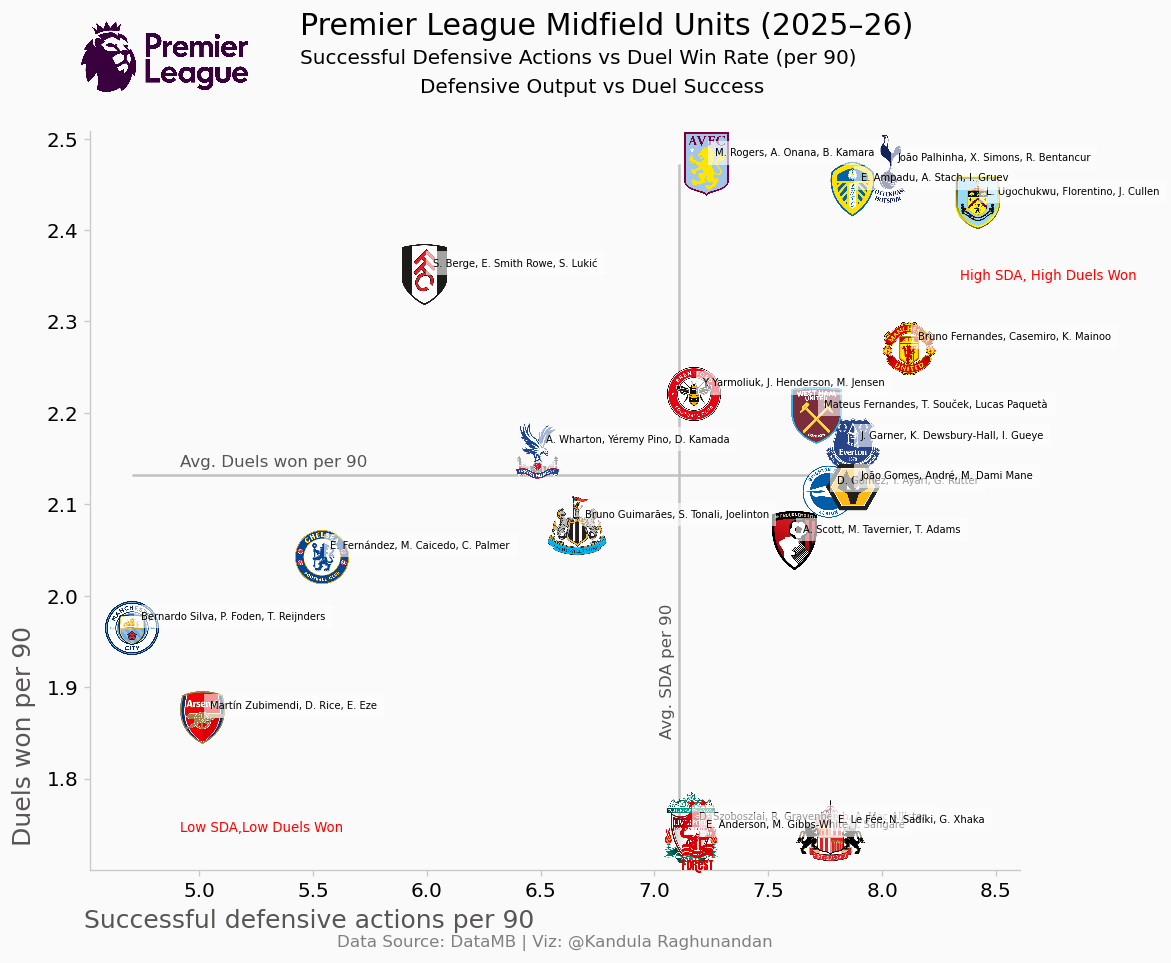

In [170]:
#Defensive Stats
#plt.rcParams.update({'font.family':'Avenir'})
bgcol = '#fafafa'

fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
fig.set_facecolor(bgcol)
ax.set_facecolor(bgcol)

x = final_df['Successful defensive actions per 90']
y = final_df['Duels won_p90']

for i, player in enumerate(final_df["Player"]):
    ax.annotate(
        player,
        (
            final_df["Successful defensive actions per 90"].iloc[i],
            final_df["Duels won_p90"].iloc[i]
        ),
        xytext=(5, 5),           # distance from point
        textcoords="offset points",
        fontsize=6,
        color="black",
        zorder=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        alpha=1
    )


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#ccc8c8')
ax.spines['bottom'].set_color('#ccc8c8')

plt.tick_params(axis='x', labelsize=12, color='#ccc8c8')
plt.tick_params(axis='y', labelsize=12, color='#ccc8c8')

def getImage(path):
    return OffsetImage(plt.imread(path), zoom=.09, alpha = 1)

for index, row in final_df.iterrows():
    ab = AnnotationBbox(getImage(row['path']), (row['Successful defensive actions per 90'], row['Duels won_p90']), frameon=False)
    ax.add_artist(ab)

plt.hlines(final_df['Duels won_p90'].mean(), final_df['Successful defensive actions per 90'].min(), final_df['Successful defensive actions per 90'].max(), color='#c2c1c0')
plt.vlines(final_df['Successful defensive actions per 90'].mean(), final_df['Duels won_p90'].min(), final_df['Duels won_p90'].max(), color='#c2c1c0')

fig.text(.06,.14,'Duels won per 90', size=15, color='#575654',rotation=90)
fig.text(.12,0.05,'Successful defensive actions per 90', size=15, color='#575654')

fig.text(.2,.53,'Avg. Duels won per 90', size=10, color='#575654')
fig.text(.6,.25,'Avg. SDA per 90', size=10, color='#575654',rotation=90)

fig.text(.2,.15,"Low SDA,Low Duels Won ",color="red",size="8")
fig.text(.85,.725,"High SDA, High Duels Won",color="red",size="8")

fig.text(.3,.98,'Premier League Midfield Units (2025–26)',size=18)
fig.text(.3,.95,'Successful Defensive Actions vs Duel Win Rate (per 90)', size=12)
fig.text(.4,.92,"Defensive Output vs Duel Success", size=12)

league_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

add_logo(ax,league_logo,zoom=0.05, xy=(0.08,1.1))

plt.text(
    0.5, -0.099, "Data Source: DataMB | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.savefig("C:/Users/K Raghunandan/Analyst/Results/prem_mid_def_25-26.png",bbox_inches='tight')

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

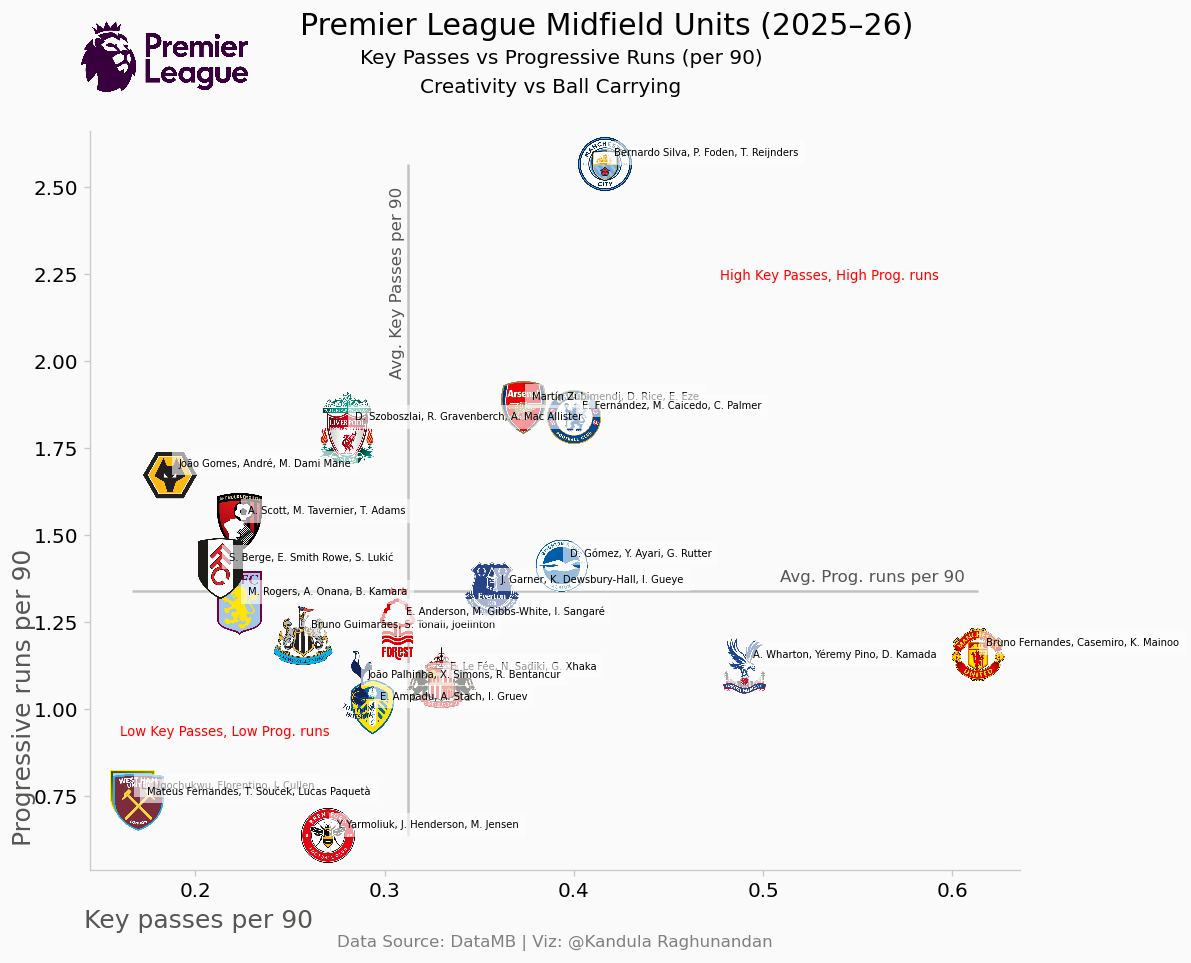

In [191]:
#Creativity
plt.rcParams.update({'font.family':'Avenir'})
bgcol = '#fafafa'

fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
fig.set_facecolor(bgcol)
ax.set_facecolor(bgcol)

x = final_df['Key passes per 90']
y = final_df['Progressive runs per 90']

for i, player in enumerate(final_df["Player"]):
    ax.annotate(
        player,
        (
            final_df["Key passes per 90"].iloc[i],
            final_df["Progressive runs per 90"].iloc[i]
        ),
        xytext=(5, 5),           # distance from point
        textcoords="offset points",
        fontsize=6,
        color="black",
        zorder=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        alpha=1
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#ccc8c8')
ax.spines['bottom'].set_color('#ccc8c8')

plt.tick_params(axis='x', labelsize=12, color='#ccc8c8')
plt.tick_params(axis='y', labelsize=12, color='#ccc8c8')

def getImage(path):
    return OffsetImage(plt.imread(path), zoom=.09, alpha = 1)

for index, row in final_df.iterrows():
    ab = AnnotationBbox(getImage(row['path']), (row['Key passes per 90'], row['Progressive runs per 90']), frameon=False)
    ax.add_artist(ab)

plt.hlines(final_df['Progressive runs per 90'].mean(), final_df['Key passes per 90'].min(), final_df['Key passes per 90'].max(), color='#c2c1c0')
plt.vlines(final_df['Key passes per 90'].mean(), final_df['Progressive runs per 90'].min(), final_df['Progressive runs per 90'].max(), color='#c2c1c0')

fig.text(.06,.14,'Progressive runs per 90', size=15, color='#575654',rotation=90)
fig.text(.12,0.05,'Key passes per 90', size=15, color='#575654')

fig.text(.7,.41,'Avg. Prog. runs per 90', size=10, color='#575654')
fig.text(.375,.625,'Avg. Key Passes per 90', size=10, color='#575654',rotation=90)

fig.text(.15,.25,"Low Key Passes, Low Prog. runs ",color="red",size="8")
fig.text(.65,.725,"High Key Passes, High Prog. runs",color="red",size="8")

fig.text(.3,.98,'Premier League Midfield Units (2025–26)',size=18)
fig.text(.35,.95,'Key Passes vs Progressive Runs (per 90)', size=12)
fig.text(.4,.92,"Creativity vs Ball Carrying", size=12)

league_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

add_logo(ax,league_logo,zoom=0.05, xy=(0.08,1.1))

plt.text(
    0.5, -0.099, "Data Source: DataMB | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.savefig("C:/Users/K Raghunandan/Analyst/Results/prem_mid_cre_25-26.png",bbox_inches='tight')

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

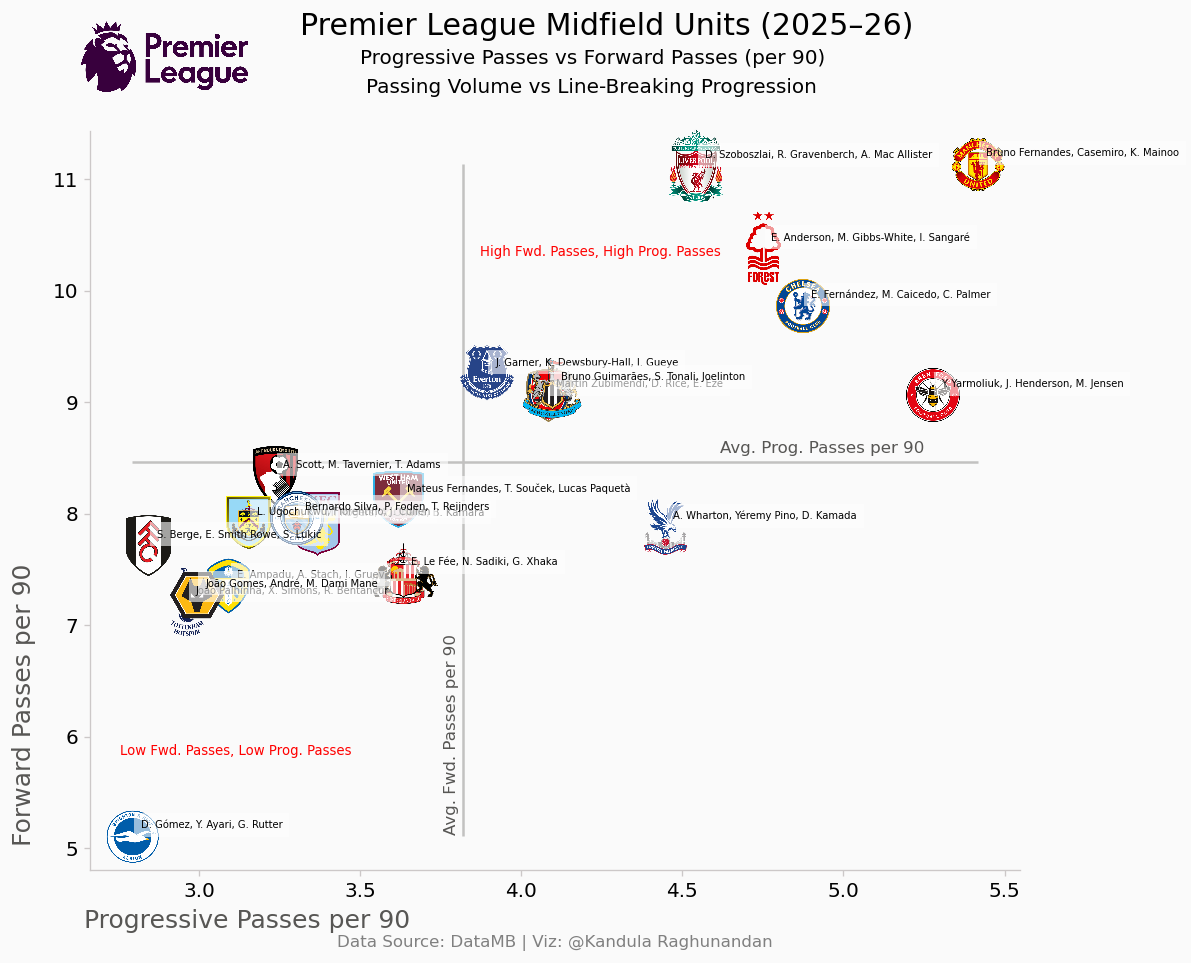

In [216]:
#progression
plt.rcParams.update({'font.family':'Avenir'})
bgcol = '#fafafa'

fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
fig.set_facecolor(bgcol)
ax.set_facecolor(bgcol)

x = final_df['Accurate progressive passes per 90']
y = final_df['Accurate forward passes per 90']

for i, player in enumerate(final_df["Player"]):
    ax.annotate(
        player,
        (
            final_df["Accurate progressive passes per 90"].iloc[i],
            final_df["Accurate forward passes per 90"].iloc[i]
        ),
        xytext=(5, 5),           # distance from point
        textcoords="offset points",
        fontsize=6,
        color="black",
        zorder=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
        alpha=1
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#ccc8c8')
ax.spines['bottom'].set_color('#ccc8c8')

plt.tick_params(axis='x', labelsize=12, color='#ccc8c8')
plt.tick_params(axis='y', labelsize=12, color='#ccc8c8')

def getImage(path):
    return OffsetImage(plt.imread(path), zoom=.09, alpha = 1)

for index, row in final_df.iterrows():
    ab = AnnotationBbox(getImage(row['path']), (row['Accurate progressive passes per 90'], row['Accurate forward passes per 90']), frameon=False)
    ax.add_artist(ab)

plt.hlines(final_df['Accurate forward passes per 90'].mean(), final_df['Accurate progressive passes per 90'].min(), final_df['Accurate progressive passes per 90'].max(), color='#c2c1c0')
plt.vlines(final_df['Accurate progressive passes per 90'].mean(), final_df['Accurate forward passes per 90'].min(), final_df['Accurate forward passes per 90'].max(), color='#c2c1c0')

fig.text(.06,.14,'Forward Passes per 90', size=15, color='#575654',rotation=90)
fig.text(.12,0.05,'Progressive Passes per 90', size=15, color='#575654')

fig.text(.65,.545,'Avg. Prog. Passes per 90', size=10, color='#575654')
fig.text(.42,.15,'Avg. Fwd. Passes per 90', size=10, color='#575654',rotation=90)

fig.text(.15,.23,"Low Fwd. Passes, Low Prog. Passes ",color="red",size="8")
fig.text(.45,.75,"High Fwd. Passes, High Prog. Passes",color="red",size="8")

fig.text(.3,.98,'Premier League Midfield Units (2025–26)',size=18)
fig.text(.35,.95,'Progressive Passes vs Forward Passes (per 90)', size=12)
fig.text(.355,.92,"Passing Volume vs Line-Breaking Progression", size=12)

league_logo = mpimg.imread("C:/Users/K Raghunandan/Analyst/Logos/Premier League/PREM LOGO (2).png")

def add_logo(ax, img, zoom, xy):
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, xy, frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

add_logo(ax,league_logo,zoom=0.05, xy=(0.08,1.1))

plt.text(
    0.5, -0.099, "Data Source: DataMB | Viz: @Kandula Raghunandan",
    ha="center", va="center",
    transform=plt.gca().transAxes,
    fontsize=10, color="gray"
)

plt.savefig("C:/Users/K Raghunandan/Analyst/Results/prem_mid_prog_25-26.png",bbox_inches='tight')